# **Modelação de tópicos com o modelo LDA (Latent Dirichlet Allocation)**

In [ ]:
# ==========================================
# Importação de bibliotecas e configuração de ambiente
# ==========================================
import pandas as pd
from pandas import DataFrame

import numpy as np
import seaborn as sns
from collections import Counter
from collections import defaultdict
import tabulate
from pathlib import Path
import pickle
import os
import time
from IPython.display import display

import spacy
import scipy.sparse

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, silhouette_score
from sklearn.cluster import KMeans

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
pyLDAvis.enable_notebook()

import gensim
from gensim import corpora, models
from gensim.models.ldamodel import LdaModel
from gensim.models import CoherenceModel, Word2Vec
from gensim.corpora import Dictionary
from gensim import matutils, models
from gensim.models import TfidfModel

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\win11\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# ==========================================
# mostra o texto completo em cada célula
# ==========================================
pd.set_option("display.max_colwidth", None)  

In [3]:
# ==========================================
# Carrega a base de dados
# ==========================================
df = pd.read_pickle("Reviews_Lisboa_RJ_200K.pkl")
print(f"A base de dados tem dimensões: {df.shape}")

A base de dados tem dimensões: (200000, 11)


In [4]:
df.head(30)

,date,comments,cidade,lang,char_count,word_count,texto_limpo,nomes_proprios,texto_anonimizado,texto_normalizado,texto_lematizado
0,2025-06-23,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada",Rio de Janeiro,pt,217,35,Os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,[],Os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,anfitrião maravilhoso casa charme macaquinho manhã varanda considerar móvel velho objeto pessoal acabar ficar cheiro forte guardar fechar
1,2022-05-02,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje .<br/>Vou falar 4 coisas que não poderia deixar passar.<br/>01- A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional.<br/>02- A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça.<br/>03- A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas.<br/>04- A localização do apartamento é fantástica pois fica pórximo a tudo.<br/>Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico !!!",Rio de Janeiro,pt,751,128,A estadia com o Renato foi a melhor experiência no Airbnb até hoje Vou falar coisas que não poderia deixar passar A vista da cobertura é sensacional um ângulo de visão da Bahia de Guanabara Pão de Açucar Aeroporto Santos Dumont e Cristo Redentor é sensacional A recepção no Chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça A flexibilidade na reserva e as dicas do RJ que o Renato passa são maravilhosas A localização do apartamento é fantástica pois fica pórximo a tudo Enfim Super indico o Renato para se hospedarem o Apartamento é fantastico,"[Renato, Renato, Renato]",A estadia com o host_anfitriao foi a melhor experiência no Airbnb até hoje Vou falar coisas que não poderia deixar passar A vista da cobertura é sensacional um ângulo de visão da Bahia de Guanabara Pão de Açucar Aeroporto Santos Dumont e Cristo Redentor é sensacional A recepção no Chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça A flexibilidade na reserva e as dicas do RJ que o host_anfitriao passa são maravilhosas A localização do apartamento é fantástica pois fica pórximo a tudo Enfim Super indico o host_anfitriao para se hospedarem o Apartamento é fantastico,a estadia com o host_anfitriao foi a melhor experiência no airbnb até hoje vou falar coisas que não poderia deixar passar a vista da cobertura é sensacional um ângulo de visão da bahia de guanabara pão de açucar aeroporto santos dumont e cristo redentor é sensacional a recepção no chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça a flexibilidade na reserva e as dicas do rj que o host_anfitriao passa são maravilhosas a localização do apartamento é fantástica pois fica pórximo

-----------
## **Criação de dicionário e corpus (Gensim)**

--------

# Remove palavras que aparecem em menos de 5 documentos ou em mais de 80% dos documentos

In [5]:
# ==========================================
# Criar o dicionário e o corpus para o modelo LDA
# ==========================================
texts = [texto.split() for texto in df["texto_lematizado"].astype(str)]

dictionary = Dictionary(texts)  # Cria o dicionário a partir dos textos processados

# ==========================================    
# Filtrar palavras muito raras e muito comuns, para reduzir o tamanho do dicionário e melhorar a qualidade dos tópicos
# ==========================================
dictionary.filter_extremes(no_below=10, no_above=0.8)    # Remove palavras que aparecem em menos de 10 documentos ou em mais de 80% dos documentos
dictionary.compactify()                                  # Reindexa o dicionário para remover os buracos deixados pelas palavras filtradas

# ==========================================
# Criar o corpus, que é a representação dos documentos como listas de tuplas (id_palavra, frequência)
# ==========================================
corpus = [dictionary.doc2bow(text) for text in texts]

# ==========================================
# Exibe o número de tokens no dicionário e o número de documentos no corpus
# ==========================================
print(f"Dicionário: {len(dictionary)} tokens")
print(f"Corpus: {len(corpus)} documentos")

Dicionário: 6961 tokens
Corpus: 200000 documentos


------
## Treinando o modelo LDA
--------

In [6]:
# ==========================================
# inicializa o tempo de início para medir o tempo total de treinamento dos modelos
# ==========================================
start_time = time.time()

# ==========================================
# configura o diretório para salvar os modelos LDA e as visualizações do pyLDAvis
# ==========================================
models_dir = os.path.join(os.getcwd(), "LDA_9-models")
os.makedirs(models_dir, exist_ok=True)

# ==========================================
# lista para armazenar os resultados de coerência dos modelos LDA e um dicionário para armazenar os modelos LDA treinados
# ==========================================
resultados = [] 
models_lda = {}

# ==========================================
# Treina modelos LDA para um número de tópicos variando de 2 a 9, calcula a coerência de cada modelo
# ===========================================
for k in range(2, 10):
    print(f"Treinando {k} tópicos...")

    LDA_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=15,
        random_state=42,
        per_word_topics=True
    )

    models_lda[k] = LDA_model
    LDA_model.save(os.path.join(models_dir, f"ldamodel_{k}topics.model"))

    coherence_model_lda = CoherenceModel(
        model=LDA_model,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )
    coherence_lda = coherence_model_lda.get_coherence()

# ==========================================
# Salva a visualização do pyLDAvis para cada modelo LDA treinado
# mantendo a ordem original dos tópicos do modelo
# ==========================================
    vis = gensimvis.prepare(LDA_model, corpus, dictionary, sort_topics=False)
    pyLDAvis.save_html(vis, os.path.join(models_dir, f"ldavis_{k}topics.html"))

    resultados.append({
        "num_topics": k,
        "coherence": coherence_lda
    })

# ==========================================
# Exibe os resultados de coerência para cada modelo LDA treinado, ordenados do melhor para o pior, e o tempo total gasto para treinar os modelos
# ==========================================
print("-" * 60)
df_resultados = pd.DataFrame(resultados).sort_values("coherence", ascending=False)
print(df_resultados)
print("-" * 60)
print(f"Melhor: {df_resultados.iloc[0]['num_topics']} tópicos")
print("-" * 60)
print(f"Tempo total: {time.time() - start_time:.2f} segundos")

Treinando 2 tópicos...
Treinando 3 tópicos...
Treinando 4 tópicos...
Treinando 5 tópicos...
Treinando 6 tópicos...
Treinando 7 tópicos...
Treinando 8 tópicos...
Treinando 9 tópicos...
------------------------------------------------------------
   num_topics  coherence
3           5   0.609952
2           4   0.602251
5           7   0.598683
6           8   0.597935
7           9   0.592437
1           3   0.591441
4           6   0.575470
0           2   0.538304
------------------------------------------------------------
Melhor: 5.0 tópicos
------------------------------------------------------------
Tempo total: 3523.19 segundos


-----
## Inspecionando o modelo treinado para ver quais palavras definem cada tópico e se correspondem com LDAvis
-------

In [7]:
# ==========================================
# Exibe os tópicos do melhor modelo LDA, com as palavras mais relevantes e seus pesos
# ==========================================
best_k = 5
model_atual = models_lda[best_k]

topics = model_atual.show_topics(num_topics=best_k, num_words=10, formatted=False)

linhas = []
for topic_id, palavras in topics:
    linhas.append({
        "topico": f"Topic {topic_id}",
        "palavras": ", ".join([palavra for palavra, peso in palavras]),
        "pesos": ", ".join([f"{peso:.4f}" for palavra, peso in palavras])
    })

df_topics = pd.DataFrame(linhas)
display(df_topics)

,topico,palavras,pesos
0,Topic 0,"host_anfitriao, casa, voltar, super, estadia, recomendar, maravilhoso, receber, limpo, igada","0.0770, 0.0434, 0.0253, 0.0231, 0.0173, 0.0157, 0.0153, 0.0152, 0.0146, 0.0125"
1,Topic 1,"cama, cozinha, ficar, problema, banheiro, haver, ter, banho, pessoa, pequeno","0.0168, 0.0138, 0.0125, 0.0118, 0.0115, 0.0112, 0.0112, 0.0089, 0.0083, 0.0080"
2,Topic 2,"restaurante, metrô, localização, metro, estação, mercado, ficar, ótimo, supermercado, excelente","0.0553, 0.0309, 0.0304, 0.0300, 0.0279, 0.0259, 0.0218, 0.0173, 0.0165, 0.0161"
3,Topic 3,"localização, excelente, limpo, ótimo, recomendar, estadia, host_anfitriao, super, anfitrião, espaço","0.0598, 0.0536, 0.0456, 0.0398, 0.0380, 0.0293, 0.0291, 0.0264, 0.0256, 0.0217"
4,Topic 4,"lisboa, espaço, acesso, casa, fácil, centro, agradável, cidade, transporte, turístico","0.0503, 0.0260, 0.0215, 0.0189, 0.0187, 0.0159, 0.0158, 0.0158, 0.0141, 0.0130"


## **Analise do Resultado do calculo de Coerencia do Modelo LDA**

O calculo de coerencia do modelo LDA resultou em 5 tópicos como solução ótima, com base na métrica de **coerência = 0.609952 (k=5)**, com divisões clara e concisas, gerando tópicos interpretáveis e bem delimitados, capturando de forma equilibrada os principais padrões do dataset sem redundâncias, garantindo melhor interpretabilidade, tais como:

**TÓPICO 1 - EXPERIENCIAS DE HOSPEDAGEM**<BR>
• Palavras-chave: sentir, voltar, maravilhoso, estadia, experiencia, hospitalidade<BR>
• Interpretação: Vivências e interações percebidas pelo hóspede durante toda a estadia 

**TÓPICO 2 - CARACTERÍSTICAS DO QUARTO/APARTAMENTO**<BR>
• Palavras-chave: cama, cozinha, banheiro, chuveiro, toalha, utensílio<BR>
• Interpretação: Atributos específicos do alojamento individual

**TÓPICO 3 - LOCALIZAÇÃO DO IMÓVEL**<BR>
• Palavras-chave: praia, restaurantes, metrô, acesso, mercado, farmácia<BR>
• Interpretação: Localização, vizinhança, atrações e acessibilidade local

**TÓPICO 4 - ANFITRIÃO / SERVIÇO**<BR>
• Palavras-chave: prestativo, receptivo, proativo, anfitrião, comunicação <BR>
• Interpretação: Qualidade do serviço humano e interação com clientes

**TÓPICO 5 - CIDADE DE LISBOA**<BR>
• Palavras-chave: Lisboa, óptimo, sintra, cascal, belém, alfama<BR>
• Interpretação: Carcteristicas da cidade de Lisboa

-------
# **Medida Estatistica - TfIdf**
## Apoio a análise e interpretação dos resultados

--------

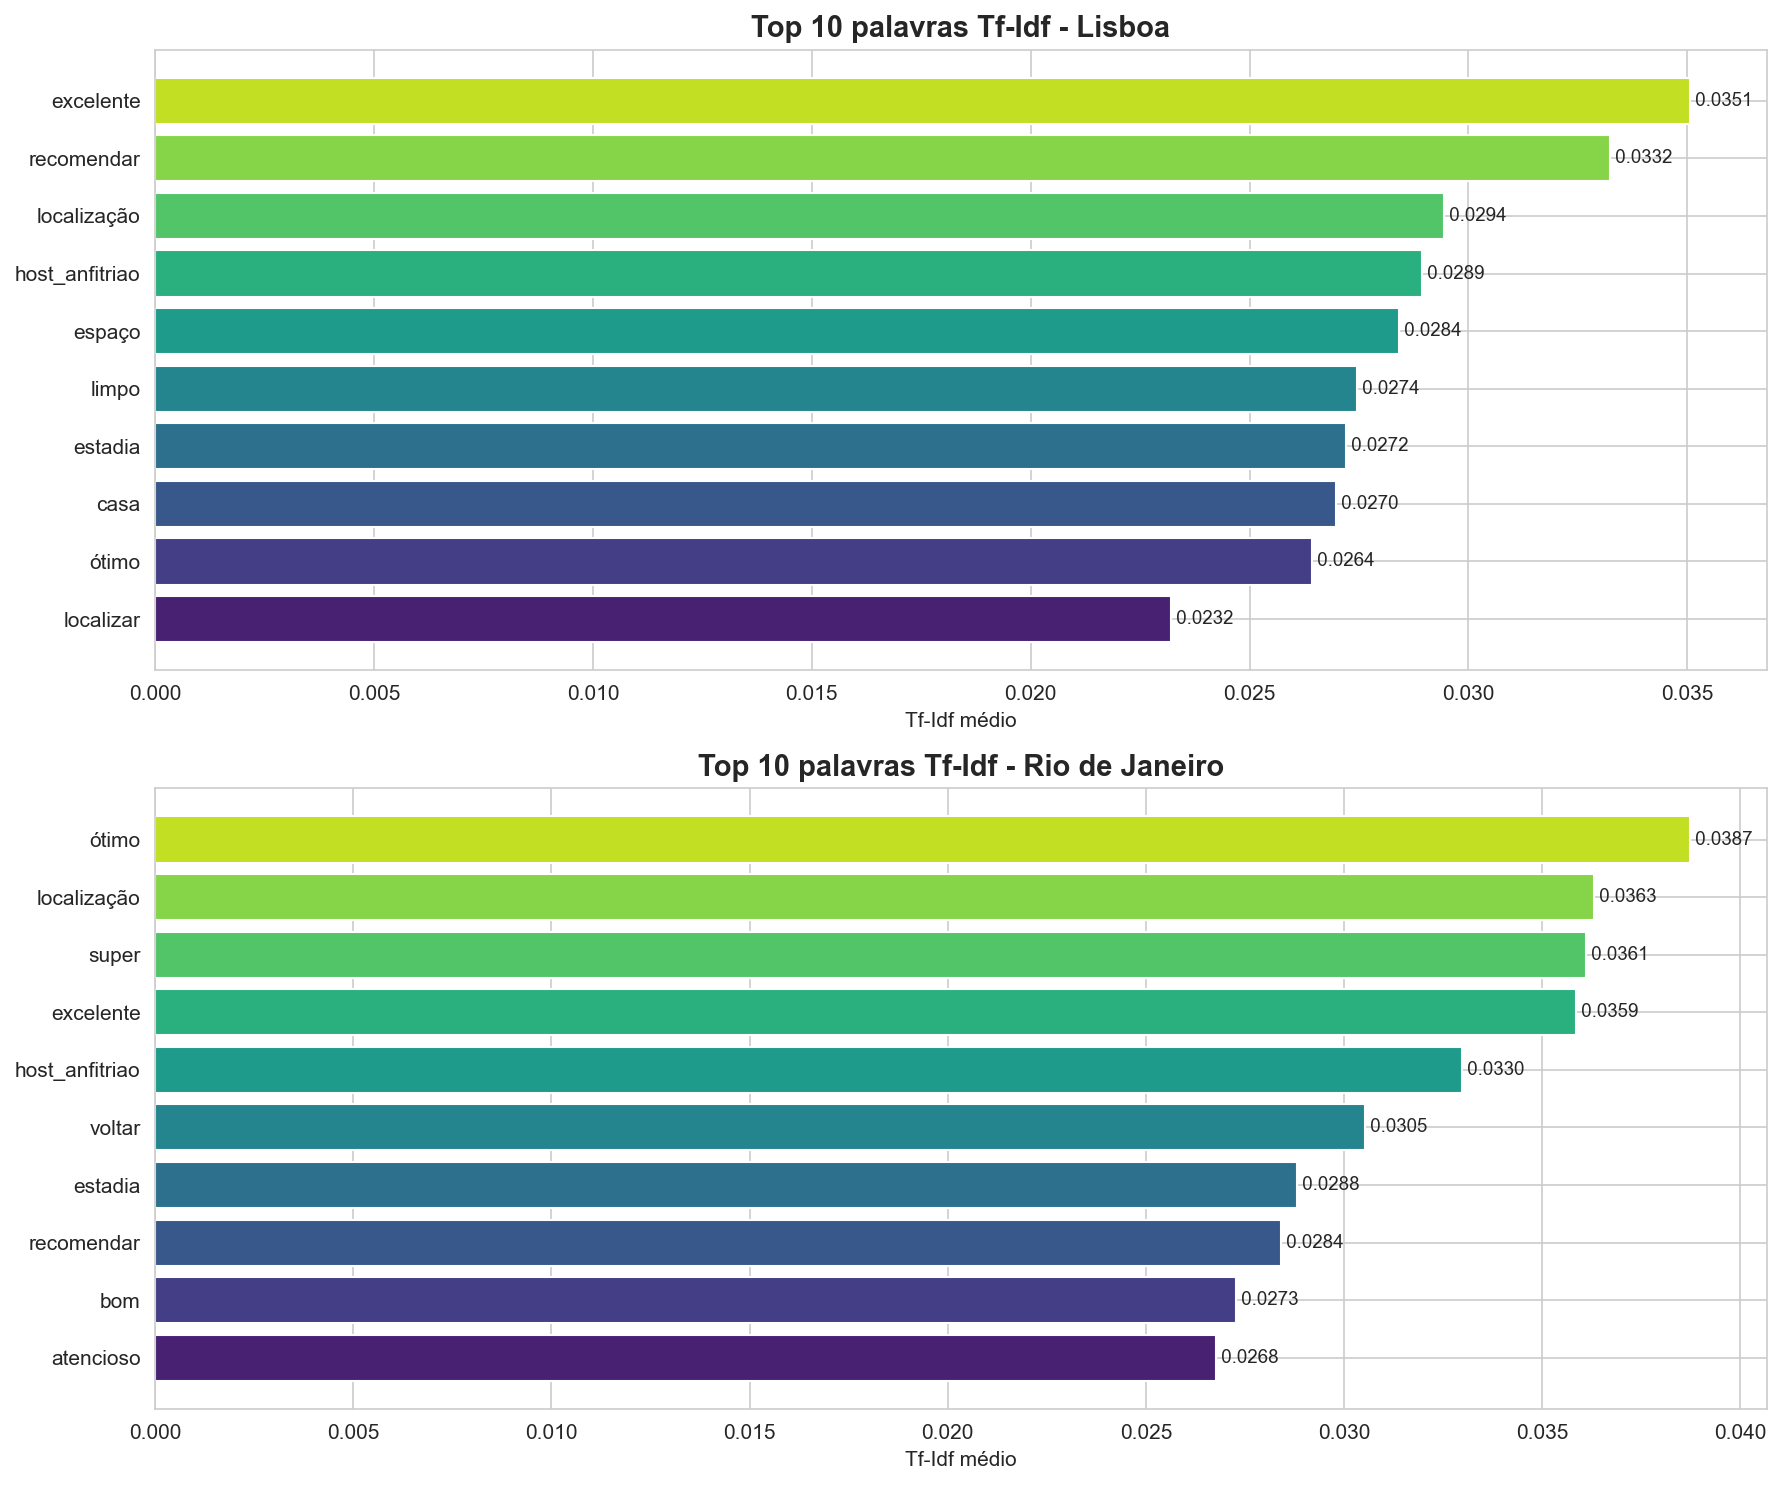

In [9]:
# =========================================
# Pasta de saída para os resultados do modelo Tf-Idf
# =========================================
models_dir = Path.cwd() / "LDA_9-models"
outdir = models_dir / "TfIdf_Results"
outdir.mkdir(parents=True, exist_ok=True)

# =========================================
# Carrega a base de dados
# =========================================
df = pd.read_pickle("Reviews_Lisboa_RJ_200k_lema_str.pkl")

# =========================================
# Prepara os dados para o modelo Tf-Idf (Gensim)
# =========================================
use = df[["cidade", "texto_lematizado"]].dropna().copy()
use["cidade"] = use["cidade"].astype(str).str.strip()
use["texto_lematizado"] = use["texto_lematizado"].astype(str).str.strip()

# =========================================
# Converte cada texto em lista de tokens
# =========================================
docs = [t.split() for t in use["texto_lematizado"]]

# =========================================
# Cria o dicionário e o corpus para o modelo Tf-Idf
# =========================================
dictionary = Dictionary(docs)

corpus_bow = [dictionary.doc2bow(doc) for doc in docs]  # Cria o corpus BoW a partir dos documentos processados
tfidf_model = TfidfModel(corpus_bow)                    # Treina o modelo Tf-Idf usando o corpus BoW
corpus_tfidf = list(tfidf_model[corpus_bow])            # Aplica o modelo Tf-Idf ao corpus BoW para obter a representação Tf-Idf dos documentos

# =========================================
# Agregar scores Tf-Idf por cidade e termo, e contar o número de documentos por cidade
# =========================================
city_scores = defaultdict(lambda: defaultdict(float))
city_n = defaultdict(int)

for i, doc_tfidf in enumerate(corpus_tfidf):
    city = use.iloc[i]["cidade"]
    city_n[city] += 1
    for term_id, score in doc_tfidf:
        city_scores[city][dictionary[term_id]] += float(score)

rows = []
for city, scores in city_scores.items():
    n = city_n[city]
    avg = {term: score / n for term, score in scores.items()}
    for term, score in sorted(avg.items(), key=lambda x: x[1], reverse=True)[:10]:
        rows.append({
            "cidade": city,
            "termo": term,
            "tfidf_medio": score
        })

# =========================================
# Salva os resultados em CSV e gera um gráfico de barras para cada cidade
# =========================================
df_top10 = pd.DataFrame(rows).sort_values(["cidade", "tfidf_medio"], ascending=[True, False])

csv_path = outdir / "top10_tfidf_por_cidade.csv"
df_top10.to_csv(csv_path, index=False)

cities = list(df_top10["cidade"].drop_duplicates())

# =========================================
# Configurações para o gráfico de barras 
# =========================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(nrows=len(cities), ncols=1, figsize=(12, 5 * len(cities)), dpi=150)
if len(cities) == 1:
    axes = [axes]

palette = sns.color_palette("viridis", 10)

for ax, city in zip(axes, cities):
    sub = df_top10[df_top10["cidade"] == city].sort_values("tfidf_medio", ascending=True)
    ax.barh(sub["termo"], sub["tfidf_medio"], color=palette)
    ax.set_title(f"Top 10 palavras Tf-Idf - {city}", fontsize=14, weight="bold")
    ax.set_xlabel("Tf-Idf médio")
    ax.set_ylabel("")
    for y, v in enumerate(sub["tfidf_medio"]):
        ax.text(v, y, f" {v:.4f}", va="center", fontsize=9)

plt.tight_layout()
png_path = outdir / "top10_tfidf_por_cidade.png"
plt.savefig(png_path, bbox_inches="tight")
plt.show()

--------
# Inferencia de Tópicos por cidade
------------

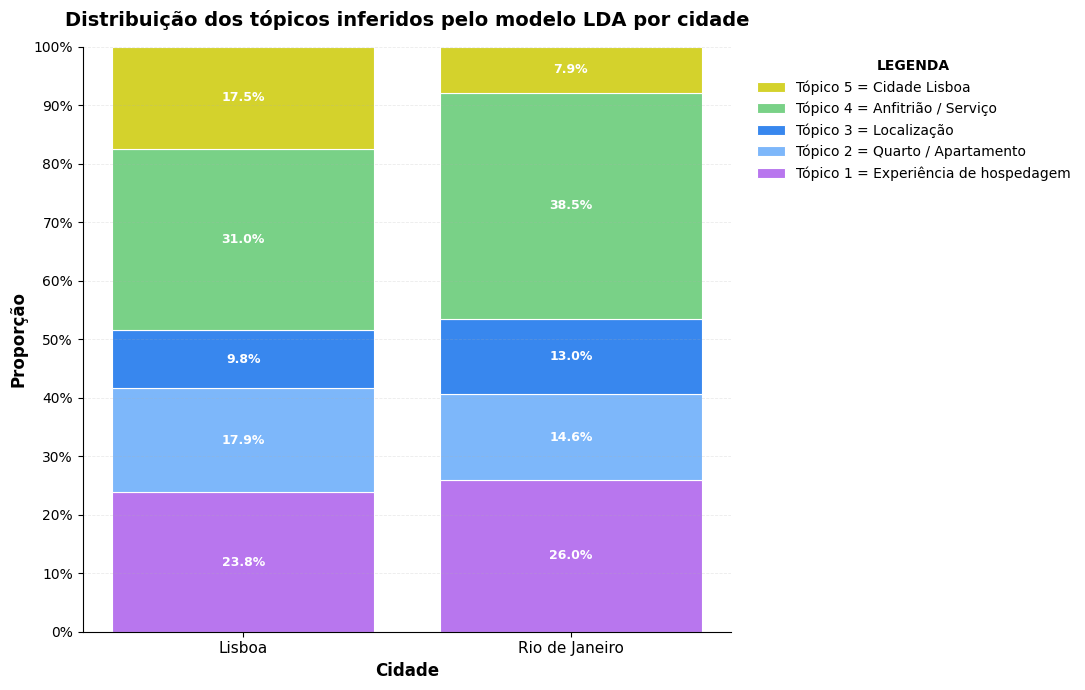

In [8]:
# =========================================================
# Caminhos
# =========================================================
models_dir = Path("LDA_9-models")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# =========================================
# 1. Carregar o modelo LDA e o dicionário
# =========================================
lda = gensim.models.LdaModel.load(os.path.join(models_dir, 'ldamodel_5topics.model'))
dictionary = corpora.Dictionary.load(os.path.join(models_dir, 'ldamodel_5topics.model.id2word'))

# =========================================
# 2. Preparar a coluna "texto_lematizado"
# =========================================
# Se a coluna estiver em formato string com palavras separadas por espaço
df['texto_lematizado_tokens'] = df['texto_lematizado'].astype(str).apply(lambda x: x.split())

# =========================================
# 3. Converter os textos para Bag-of-Words
# =========================================
corpus = [dictionary.doc2bow(texto) for texto in df['texto_lematizado_tokens']]

# =========================================
# 4. Inferir distribuição de tópicos por documento
# =========================================
doc_topics = [lda.get_document_topics(bow, minimum_probability=0.0) for bow in corpus]

topic_cols = [f'topico_{i}' for i in range(lda.num_topics)]
topic_matrix = []

for doc in doc_topics:
    row = [0.0] * lda.num_topics
    for topic_id, prob in doc:
        row[topic_id] = prob
    topic_matrix.append(row)

topic_df = pd.DataFrame(topic_matrix, columns=topic_cols)

# Juntar ao dataframe original
df_final = pd.concat([df, topic_df], axis=1)


# =========================================
# 6. Distribuição média dos tópicos por cidade
# =========================================
city_topics = df_final.groupby('cidade')[topic_cols].mean()

# =========================================
# 7. Nomes dos tópicos
# =========================================
nomes_topicos = {
    "topico_0": "Tópico 1 = Experiência de hospedagem",
    "topico_1": "Tópico 2 = Quarto / Apartamento",
    "topico_2": "Tópico 3 = Localização",
    "topico_3": "Tópico 4 = Anfitrião / Serviço",
    "topico_4": "Tópico 5 = Cidade Lisboa"
}

# ==========================================
# Definir as cores para os tópicos no gráfico de barras empilhadas
# ==========================================
cores = ["#B876EE", "#7DB7FA", "#3887EE", "#79D187", "#D4D22C"]

# =========================================
# 9. Gráfico de barras empilhadas por cidade
# =========================================
fig, ax = plt.subplots(figsize=(11, 7))

x = np.arange(len(city_topics.index))
bottom = np.zeros(len(city_topics.index))

for col, cor in zip(topic_cols, cores):
    valores = city_topics[col].values

    ax.bar(
        x,
        valores,
        bottom=bottom,
        color=cor,
        edgecolor='white',
        linewidth=0.8,
        label=nomes_topicos[col]
    )

    for i, v in enumerate(valores):
        if v > 0.03:
            ax.text(
                x[i],
                bottom[i] + v / 2,
                f'{v*100:.1f}%',
                ha='center',
                va='center',
                color='white',
                fontsize=9,
                fontweight='bold'
            )

    bottom += valores

# =========================================
# 10. Formatação do gráfico
# =========================================
ax.set_title('Distribuição dos tópicos inferidos pelo modelo LDA por cidade', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Cidade', fontsize=12, fontweight='bold')
ax.set_ylabel('Proporção', fontsize=12, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(city_topics.index, fontsize=11)

ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.set_yticklabels([f'{int(i*100)}%' for i in np.arange(0, 1.01, 0.1)])

# inverter legenda para aparecer do Tópico 5 ao Tópico 1
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title='LEGENDA',
    title_fontproperties={'weight': 'bold'},
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.6)

plt.tight_layout()
plt.savefig(output_dir / 'grafico_topicos_empilhado_por_cidade.png', dpi=300, bbox_inches='tight')
plt.show()